In [ ]:
import numpy as np
import pandas as pd
import os
import statsmodels.api as sm
from plotnine import *
np.random.seed(12345)

In [ ]:
### Problem 1

## Likelihood for a sequence of Bernoulli trials:  0, 0, 1, 0, 0, 1, 1, 1, 0, 0.

## (i) Intuitive guess - 4/10 = 0,4

## (ii)
def likelihood_b(p):
    return (p**4)*(1-p)**6

## (iii)

p_alternatives = [x/100 for x in range(101)]

likelihood_values = [likelihood_b(x) for x in p_alternatives]

print(likelihood_values)

[0.0, 9.41480149401e-09, 1.4173478093824e-07, 6.747073239924897e-07, 2.0038599416217597e-06, 4.59432431640625e-06, 8.940712362485754e-06, 1.553423430461049e-05, 2.4836300855050244e-05, 3.725790162641001e-05, 5.314410000000001e-05, 7.276303080960001e-05, 9.629883143553022e-05, 0.00012384797927018053, 0.0001554185490498458, 0.0001909319422851562, 0.00023022667799986173, 0.0002730638692415225, 0.0003191340433940583, 0.00036806499623740413, 0.00041943040000000023, 0.00047275891437179604, 0.0005275435766251623, 0.0005832512726648586, 0.0006393321150323097, 0.0006952285766601562, 0.0007503842505466778, 0.0008042521255325246, 0.0008563022870505064, 0.0009060289691192874, 0.0009529568999999997, 0.0009966468988672815, 0.0010367006945994337, 0.001072764950402426, 0.0011045344894858133, 0.0011317547274414062, 0.001154223326374134, 0.0011717910942352166, 0.0011843621602467941, 0.0011918934638208622, 0.0011943936, 0.0011919210692192587, 0.001184581983143947, 0.0011725272815132852, 0.001155949517351

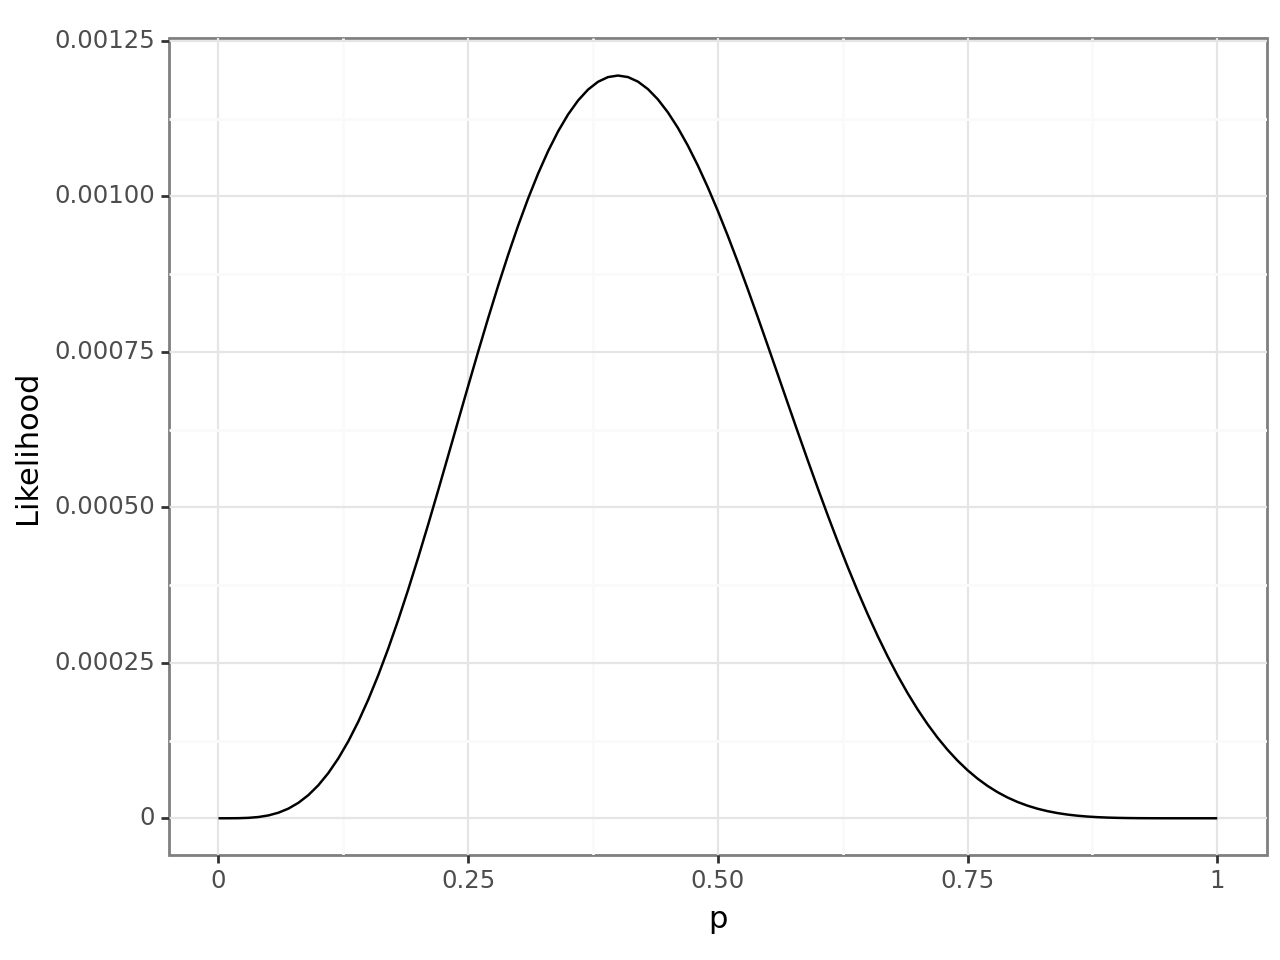

In [ ]:
## (iv)

data_plot = pd.DataFrame({'p_alts': p_alternatives,
                          'likelihood_vals': likelihood_values})
plot = (ggplot(data_plot, aes(x = 'p_alts'))+
        geom_line(aes(y = 'likelihood_vals'), linetype = 'solid', colour = 'black')+
        theme_bw()+
        ylab('Likelihood')+
        xlab('p'))
print(plot)

In [ ]:
## (v)

from scipy.optimize import minimize

def likelihood_b(p):
    return -(p**4)*(1-p)**6
def derivative_b(p):
  return -2*(((p-1)**5)*p**3)*(5*p-2)

optim_bernoulli = minimize(likelihood_b, x0 = 0.6, method = "Newton-CG", jac=derivative_b)
print(optim_bernoulli)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -0.0011943935999999013
       x: [ 4.000e-01]
     nit: 4
     jac: [-3.134e-09]
    nfev: 6
    njev: 10
    nhev: 0


In [ ]:
print("In the result of minimization we received x = 4.000e-01, what corresponds to our initial intuitive guess that the likelihood will be 0,4.")

In the result of minimization we received x = 4.000e-01, what corresponds to our initial intuitive guess that the likelihood will be 0,4.


In [ ]:
### Problem 3 (Wooldridge, Chapter 8, exercise C2)

## (0) - Preparing the data.

from google.colab import files
uploaded = files.upload()

Saving hprice1.xls to hprice1.xls


In [ ]:
df1 = pd.read_excel("/content/hprice1.xls")

df1

,300.000000,349.100000,4.000000,6126.000000,2438.000000,1.000000,5.703783,5.855359,8.720297,7.798934
0,370.000,351.5,3,9903,2076,1,5.913503,5.862210,9.200593,7.638198
1,191.000,217.7,3,5200,1374,0,5.252274,5.383118,8.556414,7.225482
2,195.000,231.8,3,4600,1448,1,5.273000,5.445875,8.433811,7.277938
3,373.000,319.1,4,6095,2514,1,5.921578,5.765504,8.715224,7.829630
4,466.275,414.5,5,8566,2754,1,6.144775,6.027073,9.055556,7.920810
...,...,...,...,...,...,...,...,...,...,...
82,295.000,318.3,3,6056,1837,1,5.686975,5.762994,8.708805,7.515889
83,236.000,259.4,3,5828,1715,0,5.463832,5.558371,8.670429,7.447168
84,202.500,258.1,3,6341,1574,0,5.310740,5.553347,8.754792,7.361375
85,219.000,232.0,2,6362,1185,0,5.389072,5.446737,8.758098,7.077498


In [ ]:
column_hprice_names = ["price", "assess", "bdrms", "lotsize", "sqrft", "colonial", "lprice", "lassess",
                       "llotsize", "lsqrft"]
data_hprice_named = pd.read_excel('/content/hprice1.xls', header=None, names=column_hprice_names)

data_hprice_named

,price,assess,bdrms,lotsize,sqrft,colonial,lprice,lassess,llotsize,lsqrft
0,300.0,349.1,4,6126,2438,1,5.703783,5.855359,8.720297,7.798934
1,370.0,351.5,3,9903,2076,1,5.913503,5.862210,9.200593,7.638198
2,191.0,217.7,3,5200,1374,0,5.252274,5.383118,8.556414,7.225482
3,195.0,231.8,3,4600,1448,1,5.273000,5.445875,8.433811,7.277938
4,373.0,319.1,4,6095,2514,1,5.921578,5.765504,8.715224,7.829630
...,...,...,...,...,...,...,...,...,...,...
83,295.0,318.3,3,6056,1837,1,5.686975,5.762994,8.708805,7.515889
84,236.0,259.4,3,5828,1715,0,5.463832,5.558371,8.670429,7.447168
85,202.5,258.1,3,6341,1574,0,5.310740,5.553347,8.754792,7.361375
86,219.0,232.0,2,6362,1185,0,5.389072,5.446737,8.758098,7.077498


In [ ]:
data_hprice_named = data_hprice_named.loc[(data_hprice_named['price']!='.') & (data_hprice_named['lotsize']!='.')
                 & (data_hprice_named['sqrft']!='.') & (data_hprice_named['bdrms']!='.')]

data_hprice_estimation = pd.DataFrame({'Intercept':[1]*len(data_hprice_named),
                          'price': data_hprice_named['price'],
                          'lotsize': data_hprice_named['lotsize'],
                          'sqrft': data_hprice_named['sqrft'],
                          'bdrms': data_hprice_named['bdrms']})

data_hprice_estimation = data_hprice_estimation.astype(float)

data_hprice_estimation.describe(include = 'all')

,Intercept,price,lotsize,sqrft,bdrms
count,88.0,88.000000,88.000000,88.000000,88.000000
mean,1.0,293.546034,9019.863636,2013.693182,3.568182
std,0.0,102.713445,10174.150414,577.191583,0.841393
min,1.0,111.000000,1000.000000,1171.000000,2.000000
25%,1.0,230.000000,5732.750000,1660.500000,3.000000
50%,1.0,265.500000,6430.000000,1845.000000,3.000000
75%,1.0,326.250000,8583.250000,2227.000000,4.000000
max,1.0,725.000000,92681.000000,3880.000000,7.000000


In [ ]:
## (i)

model_hprice = sm.OLS.from_formula('price ~lotsize + sqrft + bdrms', data = data_hprice_estimation)
results_hprice = model_hprice.fit(cov_type = "HC3")

print(results_hprice.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     19.54
Date:                Mon, 26 Feb 2024   Prob (F-statistic):           1.06e-09
Time:                        13:44:37   Log-Likelihood:                -482.88
No. Observations:                  88   AIC:                             973.8
Df Residuals:                      84   BIC:                             983.7
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.7703     41.033     -0.531      0.5

In [ ]:
print("With heteroskedasticity-robust standard errors they significantly increase in value compared to usual standard errors values of which were presented in equation 8.17.")

In [ ]:
## (ii)

model_hpricelog = sm.OLS.from_formula('np.log(price) ~np.log(lotsize) + np.log(sqrft) + bdrms', data = data_hprice_estimation)
results_hpricelog = model_hpricelog.fit(cov_type = "HC3")

print(results_hpricelog.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     44.82
Date:                Mon, 26 Feb 2024   Prob (F-statistic):           2.14e-17
Time:                        13:44:42   Log-Likelihood:                 25.861
No. Observations:                  88   AIC:                            -43.72
Df Residuals:                      84   BIC:                            -33.81
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.2970      0.850     

In [ ]:
print("With heteroskedasticity-robust standard errors they also increase in value compared to usual standard errors values of which were presented in equation 8.18, but not as much as was in the case of (i).")

## (iii)

print("This example suggests that, as it was stated in Wooldridge, Chapter 8, example 8.4, logarithmic form of the dependent variable indeed allows to reduce heteroskedasticity.")

In [ ]:
### Problem 4

## (i)

def likelihood_bin(p,sequence, n):
    final_product = 1
    for k in sequence:
        first_el = np.math.factorial(n)/(np.math.factorial(k)*np.math.factorial(n-k))
        final_product *= first_el*p**k*(1-p)**(n-k)
    return -final_product

def derivative_b(p, sequence, n):
  return np.sum(sequence)-p*10*n

p_estimates = [0]

p = 0
sequence = [1, 3, 2, 4, 3, 5, 1, 0, 2, 1]

p_estimates = [0]

p = 0

likelihood_old = 0.9
learning_rate = 0.01

likelihood = []
for x in range(101):

    p = p + learning_rate*derivative_b(p, sequence, 10)
    p_estimates += [p]

    likelihood_new = likelihood_bin(p, sequence, 10)
    likelihood += [likelihood_new]

    if abs(likelihood_new - likelihood_old) <0.00000001:
        break
    likelihood_old = likelihood_new

print(p)

0.22


<ipython-input-50-7a287292f646>:8: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`


In [ ]:
len(p_estimates)

101

In [ ]:
## (ii)

from scipy.optimize import minimize

def likelihood_bin(p,sequence, n):
    final_product = 1
    for k in sequence:
        first_el = np.math.factorial(n)/(np.math.factorial(n)*np.math.factorial(n-k))
        final_product *= first_el*p**k*(1-p)**(n-k)
    return -final_product

sequence = [1, 3, 2, 4, 3, 5, 1, 0, 2, 1]

optim_bernoulli1 = minimize(likelihood_bin, x0 = 0, method = "nelder-mead", args = (sequence, 10))
print(optim_bernoulli1.x)

[0.22]


<ipython-input-44-ca7a3e43fbac>:10: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`


In [ ]:
print("Results are similar if we take learning rate = 0,01 for the Gradient descent calculation.")

In [ ]:
### Problem 6 (wooldridge, Chapter 4, exercise C6)

## (0) - preparing the data

from google.colab import files
uploaded = files.upload()

Saving wage2.xls to wage2.xls


In [ ]:
df2 = pd.read_excel("/content/wage2.xls")

df2

,769,40,93,35,12,11,2,31,1,0,0.1,1.1,1.2,2.1,8,8.1,6.645091
0,808,50,119,41,18,11,16,37,1,0,0,1,1,.,14,14,6.694562
1,825,40,108,46,14,11,9,33,1,0,0,1,1,2,14,14,6.715384
2,650,40,96,32,12,13,7,32,1,0,0,1,4,3,12,12,6.476973
3,562,40,74,27,11,14,5,34,1,0,0,1,10,6,6,11,6.331502
4,1400,40,116,43,16,14,2,35,1,1,0,1,1,2,8,.,7.244227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,520,40,79,28,16,6,1,30,1,1,1,0,0,1,11,.,6.253829
930,1202,40,102,32,13,10,3,31,1,0,1,1,7,7,8,6,7.091742
931,538,45,77,22,12,12,10,28,1,1,1,0,9,.,7,.,6.287858
932,873,44,109,25,12,12,12,28,1,0,1,0,1,1,.,11,6.771935


In [ ]:
column_names = ["wage", "hours", "IQ", "KWW", "educ", "exper", "tenure", "age",
                "married", "black", "south", "urban", "sibs", "brthord", "meduc", "feduc",
                "lwage"]
data_wage2_named = pd.read_excel('/content/wage2.xls', header=None, names=column_names)

data_wage2_named

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,769,40,93,35,12,11,2,31,1,0,0,1,1,2,8,8,6.645091
1,808,50,119,41,18,11,16,37,1,0,0,1,1,.,14,14,6.694562
2,825,40,108,46,14,11,9,33,1,0,0,1,1,2,14,14,6.715384
3,650,40,96,32,12,13,7,32,1,0,0,1,4,3,12,12,6.476973
4,562,40,74,27,11,14,5,34,1,0,0,1,10,6,6,11,6.331502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930,520,40,79,28,16,6,1,30,1,1,1,0,0,1,11,.,6.253829
931,1202,40,102,32,13,10,3,31,1,0,1,1,7,7,8,6,7.091742
932,538,45,77,22,12,12,10,28,1,1,1,0,9,.,7,.,6.287858
933,873,44,109,25,12,12,12,28,1,0,1,0,1,1,.,11,6.771935


In [ ]:
data_wage2_named = data_wage2_named.loc[(data_wage2_named['wage']!='.') & (data_wage2_named['educ']!='.') & (data_wage2_named['exper']!='.')
                 & (data_wage2_named['tenure']!='.')]

data_wage2_estimation = pd.DataFrame({'Intercept':[1]*len(data_wage2_named),
                          'log_wage': np.log(data_wage2_named.wage),
                          'educ': data_wage2_named['educ'],
                          'exper': data_wage2_named['exper'],
                          'tenure': data_wage2_named['tenure']})

data_wage2_estimation = data_wage2_estimation.astype(float)

data_wage2_estimation.describe(include = 'all')

,Intercept,log_wage,educ,exper,tenure
count,935.0,935.000000,935.000000,935.000000,935.000000
mean,1.0,6.779004,13.468449,11.563636,7.234225
std,0.0,0.421144,2.196654,4.374586,5.075206
min,1.0,4.744932,9.000000,1.000000,0.000000
25%,1.0,6.505783,12.000000,8.000000,3.000000
50%,1.0,6.807935,12.000000,11.000000,7.000000
75%,1.0,7.056175,16.000000,15.000000,11.000000
max,1.0,8.032035,18.000000,23.000000,22.000000


In [ ]:
## Running the model

model_wage2 = sm.OLS.from_formula('log_wage ~educ + exper + tenure', data = data_wage2_estimation)
results_wage2 = model_wage2.fit()

print(results_wage2.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     56.97
Date:                Mon, 26 Feb 2024   Prob (F-statistic):           8.12e-34
Time:                        17:17:42   Log-Likelihood:                -438.84
No. Observations:                 935   AIC:                             885.7
Df Residuals:                     931   BIC:                             905.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4967      0.111     49.731      0.0

In [ ]:
import statsmodels.api as sm

## (i)

hypothesis0 = 'exper = tenure'

## (ii)

h0_test = results_wage2.f_test(hypothesis0)

print(not (h0_test.pvalue > 0.975) or (h0_test.pvalue < 0.025))

True


In [ ]:
print("We failed to reject the null hypotheses. This means that another year of general workforce experience and another year of tenure actually have same effect on log(wage)")

In [ ]:
### Problem 7 (Wooldridge, Chapter 4, exercise C11)

## Preparing the data

from google.colab import files
uploaded = files.upload()

Saving htv.xls to htv.xls


In [ ]:
df3 = pd.read_excel("/content/htv.xls")

df3

,12.01923,5.027738,15,0,0.1,1,0.2,9,12,12.1,...,1.3,0.4,0.5,0.6,1.4,7.582914,7.260242,2.486508,81,-0.3226714
0,8.912656,2.037170,13,1,0,0,0,8,12,10,...,1,0,0,0,1,8.595144,9.499537,2.187472,64,0.904392
1,15.514330,2.475895,15,1,0,0,0,11,12,16,...,1,0,0,0,1,7.311346,7.311346,2.741764,121,0.000000
2,13.333330,3.609240,15,1,0,0,0,6,12,12,...,1,0,0,0,1,9.499537,10.162070,2.590267,36,0.662534
3,11.070110,2.636546,13,1,0,0,0,15,12,15,...,1,0,0,0,1,7.311346,7.311346,2.404249,225,0.000000
4,17.482520,3.474334,18,1,0,0,0,8,12,12,...,1,0,0,0,1,7.311346,7.311346,2.861201,64,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,7.735584,2.803173,12,0,0,0,1,9,12,12,...,0,0,1,0,1,3.895709,3.810777,2.045831,81,-0.084932
1225,91.309220,4.164562,19,0,0,1,0,6,13,14,...,0,0,0,1,0,0.000000,0.000000,4.514252,36,0.000000
1226,12.980770,0.893115,16,0,0,0,1,11,14,16,...,0,0,1,0,0,2.444079,2.444079,2.563469,121,0.000000
1227,12.500000,-0.633061,8,0,0,0,1,19,6,10,...,0,1,0,0,1,7.582914,7.582914,2.525729,361,0.000000


In [ ]:
column_htv_names = ["wage", "abil", "educ", "ne", "nc", "west", "south", "exper",
                "motheduc",  "fatheduc", "brkhme14", "sibs", "urban", "ne18", "nc18", "south18",
                "west18", "urban18", "tuit17", "tuit18", "lwage", "expersq", "ctuit"]
data_htv_named = pd.read_excel('/content/htv.xls', header=None, names=column_htv_names)

data_htv_named

,wage,abil,educ,ne,nc,west,south,exper,motheduc,fatheduc,...,ne18,nc18,south18,west18,urban18,tuit17,tuit18,lwage,expersq,ctuit
0,12.019230,5.027738,15,0,0,1,0,9,12,12,...,1,0,0,0,1,7.582914,7.260242,2.486508,81,-0.322671
1,8.912656,2.037170,13,1,0,0,0,8,12,10,...,1,0,0,0,1,8.595144,9.499537,2.187472,64,0.904392
2,15.514330,2.475895,15,1,0,0,0,11,12,16,...,1,0,0,0,1,7.311346,7.311346,2.741764,121,0.000000
3,13.333330,3.609240,15,1,0,0,0,6,12,12,...,1,0,0,0,1,9.499537,10.162070,2.590267,36,0.662534
4,11.070110,2.636546,13,1,0,0,0,15,12,15,...,1,0,0,0,1,7.311346,7.311346,2.404249,225,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1225,7.735584,2.803173,12,0,0,0,1,9,12,12,...,0,0,1,0,1,3.895709,3.810777,2.045831,81,-0.084932
1226,91.309220,4.164562,19,0,0,1,0,6,13,14,...,0,0,0,1,0,0.000000,0.000000,4.514252,36,0.000000
1227,12.980770,0.893115,16,0,0,0,1,11,14,16,...,0,0,1,0,0,2.444079,2.444079,2.563469,121,0.000000
1228,12.500000,-0.633061,8,0,0,0,1,19,6,10,...,0,1,0,0,1,7.582914,7.582914,2.525729,361,0.000000


In [ ]:
data_htv_named = data_htv_named.loc[(data_htv_named['educ']!='.') & (data_htv_named['motheduc']!='.')
                 & (data_htv_named['fatheduc']!='.') & (data_htv_named['abil']!='.')]

data_htv_estimation = pd.DataFrame({'Intercept':[1]*len(data_htv_named),
                                    'educ': data_htv_named['educ'],
                                    'motheduc': data_htv_named['motheduc'],
                                    'fatheduc': data_htv_named['fatheduc'],
                                    'abil': data_htv_named['abil'],
                                    'abil_squared': np.square(data_htv_named.abil)})

data_htv_estimation = data_htv_estimation.astype(float)

data_htv_estimation.describe(include = 'all')

,Intercept,educ,motheduc,fatheduc,abil,abil_squared
count,1230.0,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000
mean,1.0,13.037398,12.178049,12.447154,1.796596,7.995508
std,0.0,2.354346,2.278067,3.263835,2.184406,7.470227
min,1.0,6.000000,0.000000,0.000000,-5.631463,0.000003
25%,1.0,12.000000,12.000000,11.000000,0.566201,1.716671
50%,1.0,12.000000,12.000000,12.000000,2.149759,5.716683
75%,1.0,15.000000,12.000000,14.000000,3.461466,12.597579
max,1.0,20.000000,20.000000,20.000000,6.263742,39.234464


In [ ]:
## (i)

model_htv = sm.OLS.from_formula('educ ~motheduc + fatheduc + abil + abil_squared', data = data_htv_estimation)
results_htv = model_htv.fit()

print(results_htv.summary())

                            OLS Regression Results                            
Dep. Variable:                   educ   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     244.9
Date:                Mon, 26 Feb 2024   Prob (F-statistic):          1.34e-154
Time:                        17:27:25   Log-Likelihood:                -2436.6
No. Observations:                1230   AIC:                             4883.
Df Residuals:                    1225   BIC:                             4909.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.2402      0.287     28.671   

In [ ]:
# print(results_htv.summary().as_latex()) - this I would use if I just needed to report the results with table like the one above, but for the joint table with results for all three regressions in the form required in the task please look at the LaTeX file or PDF

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &       educ       & \textbf{  R-squared:         } &     0.444   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.443   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     244.9   \\
\textbf{Date:}             & Sat, 17 Feb 2024 & \textbf{  Prob (F-statistic):} & 1.34e-154   \\
\textbf{Time:}             &     17:25:42     & \textbf{  Log-Likelihood:    } &   -2436.6   \\
\textbf{No. Observations:} &        1230      & \textbf{  AIC:               } &     4883.   \\
\textbf{Df Residuals:}     &        1225      & \textbf{  BIC:               } &     4909.   \\
\textbf{Df Model:}         &           4      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                       & \textbf{coef} 

In [ ]:
# One way to test the hypothesis

t_values_abilsq = results_htv.params[4]/results_htv.bse[4]
t_values_abilsq

6.0934005296649

In [ ]:
from scipy.stats import t

print('p-value, abilsq:', 2*t.cdf(-abs(t_values_abilsq), len(data_htv_named) - 5))

p-value, abilsq: 1.4780607704651297e-09


In [ ]:
# Alternative way

hypothesis0_abilsq = "abil_squared = 0"

h0_abilsq_test = results_htv.f_test(hypothesis0_abilsq)

print("P-value: ", h0_abilsq_test.pvalue)

if h0_abilsq_test.pvalue < 0.05:
  print("Hypothesis 0 is rejected, and abilsq is significant and relationship is quadratic.");
else:
  print("Hypothesis 0 is not rejected, and abilsq is unsignificant and relationship is linear")

P-value:  1.4780607704661544e-09
Hypothesis 0 is rejected, and abilsq is significant and relationship is quadratic.


In [ ]:
## (ii)

hypothesis0_htv = 'motheduc = fatheduc'

h0_htv_test = results_htv.f_test(hypothesis0_htv)

print(not (h0_htv_test.pvalue > 0.975) or (h0_htv_test.pvalue < 0.025))
print("P-value of the test is:", h0_htv_test.pvalue)

True
P-value of the test is: 0.05313969031138818


In [ ]:
## (iii)

data_htv_named_tuit = data_htv_named.loc[(data_htv_named['educ']!='.') & (data_htv_named['motheduc']!='.')
                 & (data_htv_named['fatheduc']!='.') & (data_htv_named['abil']!='.') & (data_htv_named['tuit17']!='.') & (data_htv_named['tuit18']!='.')]

data_htv_estimation_tuit = pd.DataFrame({'Intercept':[1]*len(data_htv_named_tuit),
                                    'educ': data_htv_named_tuit['educ'],
                                    'motheduc': data_htv_named_tuit['motheduc'],
                                    'fatheduc': data_htv_named_tuit['fatheduc'],
                                    'abil': data_htv_named_tuit['abil'],
                                    'abil_squared': np.square(data_htv_named_tuit.abil),
                                    'tuit17': data_htv_named_tuit['tuit17'],
                                    'tuit18': data_htv_named_tuit['tuit18']})

data_htv_estimation_tuit = data_htv_estimation_tuit.astype(float)

data_htv_estimation_tuit.describe(include = 'all')


,Intercept,educ,motheduc,fatheduc,abil,abil_squared,tuit17,tuit18
count,1230.0,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000,1230.000000
mean,1.0,13.037398,12.178049,12.447154,1.796596,7.995508,8.568645,8.588090
std,0.0,2.354346,2.278067,3.263835,2.184406,7.470227,4.127664,4.051148
min,1.0,6.000000,0.000000,0.000000,-5.631463,0.000003,0.000000,0.000000
25%,1.0,12.000000,12.000000,11.000000,0.566201,1.716671,6.074849,6.125471
50%,1.0,12.000000,12.000000,12.000000,2.149759,5.716683,8.727639,8.826549
75%,1.0,15.000000,12.000000,14.000000,3.461466,12.597579,11.155030,11.155030
max,1.0,20.000000,20.000000,20.000000,6.263742,39.234464,18.173920,18.173920


In [ ]:
model_htv_plustuit = sm.OLS.from_formula('educ ~motheduc + fatheduc + abil + abil_squared + tuit17 + tuit18', data = data_htv_estimation_tuit)
results_htv_plustuit = model_htv_plustuit.fit()

print(results_htv_plustuit.summary())

                            OLS Regression Results                            
Dep. Variable:                   educ   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     163.5
Date:                Sat, 17 Feb 2024   Prob (F-statistic):          1.43e-152
Time:                        15:56:40   Log-Likelihood:                -2435.8
No. Observations:                1230   AIC:                             4886.
Df Residuals:                    1223   BIC:                             4921.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.0819      0.313     25.840   

In [ ]:
from scipy.stats import f

F = ((results_htv_plustuit.rsquared - results_htv.rsquared)/2)/((1 - results_htv_plustuit.rsquared)/(len(data_htv_named)-7))
print('p-value, F-test:', 1 - f.cdf(F, 2, len(data_htv_named)-6))

if (1 - f.cdf(F, 2, len(data_htv_named)-6)) < 0.05:
  print("Tuit17 and tuit18 are jointly significant")
else:
  print("Tuit17 and tuit18 are not jointly significant")

p-value, F-test: 0.43224840655668306
Tuit17 and tuit18 are not jointly significant


In [ ]:
# (iv)
from scipy.stats import pearsonr
print(pearsonr(data_htv_estimation_tuit['tuit17'], data_htv_estimation_tuit['tuit18']))

PearsonRResult(statistic=0.9808332587476112, pvalue=0.0)


In [ ]:
data_htv_estimation_tuit['tuit_average'] = (data_htv_named.tuit17 + data_htv_named.tuit18).mean()


model_htv_tuitav = sm.OLS.from_formula('educ ~motheduc + fatheduc + abil + abil_squared + tuit_average', data = data_htv_estimation_tuit)
results_htv_tuitav = model_htv_tuitav.fit()

print(results_htv_tuitav.summary())


                            OLS Regression Results                            
Dep. Variable:                   educ   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     244.9
Date:                Sat, 17 Feb 2024   Prob (F-statistic):          1.34e-154
Time:                        17:18:01   Log-Likelihood:                -2436.6
No. Observations:                1230   AIC:                             4883.
Df Residuals:                    1225   BIC:                             4909.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0279      0.001     28.671   

In [ ]:
print("As can be seen from the OLS Regression results, with using the average the coefficient of tuition significantly increase, while p became less than 0,05 significance level, so that tuit_average variable became significant while variables for separate ages were not. As we have established while checking correlation between tuit_17 and tuit_18, statistic is equal to 0,98, what means that the correlation is very high. High correlation implies multicollinearity, and the latter violates the third Gauss-Markov assumption (lecture 5 part 1, slide 18). Using the average eliminates multicollinearity.")

In [ ]:
## (v)

print("Causal interpretation would imply that an increase in average college tuition would lead to an increase in the years of education. This could mean that higher tuition motivates students to spend more years in education, while in reality the relation should be the opposite: higher tuition would only decrease the amount of people getting college education. The reason for the results of regression may lie in the fact that in countries with more expensive college education people have more ability to spend years as students given that in coutries with expensive college education overall welfare is probably higher, so that parents have more abilities to pay living expenses of their children so that they don't have to work instead of getting further education.")